In [1]:
import jax
import optax
import jax.numpy as jnp

In [2]:
jax.config.update("jax_enable_x64", True)

In [3]:
# prompt: a random jnp array of shape [n,D]

key = jax.random.PRNGKey(60415)
n = 10
D = 3
random_array = jax.random.uniform(key, shape=(n,D))
random_array = random_array.at[0].set([1,1,0])
random_array

Array([[1.        , 1.        , 0.        ],
       [0.02812025, 0.61337312, 0.31403046],
       [0.17958501, 0.02415364, 0.46950469],
       [0.39202959, 0.11682942, 0.54864318],
       [0.41531578, 0.75048168, 0.26785848],
       [0.00694962, 0.36125454, 0.85064899],
       [0.31058561, 0.59188133, 0.18087662],
       [0.19359209, 0.44176089, 0.97467897],
       [0.29079561, 0.36132818, 0.47691065],
       [0.44677184, 0.34216589, 0.40756697]], dtype=float64)

In [4]:
def project_and_clip_hypersphere(x):
  x = jnp.clip(x, min=0, max=1)
  return x / jnp.linalg.norm(x,axis=1,keepdims=True)

In [5]:
project_and_clip_hypersphere(random_array)

Array([[0.70710678, 0.70710678, 0.        ],
       [0.04077402, 0.88938335, 0.45534024],
       [0.35684468, 0.04799453, 0.93293001],
       [0.57284298, 0.17071394, 0.80169051],
       [0.46218775, 0.83518001, 0.29808862],
       [0.00751956, 0.39088094, 0.92041053],
       [0.44852385, 0.85474949, 0.2612081 ],
       [0.17801771, 0.40622147, 0.89626659],
       [0.43711916, 0.54314256, 0.71688423],
       [0.64299135, 0.49244309, 0.58656793]], dtype=float64)

In [6]:
def project_simplex(x):
  # x = jnp.maximum(0, jnp.minimum(1,x))
  dim = x.shape[-1]
  hyperplane_norm = jnp.ones((dim,)) / jnp.sqrt(dim)
  origin_plane_points = x - hyperplane_norm * jnp.matmul(x, hyperplane_norm[:,None])
  hyperplane_centroid = jnp.ones((dim,)) / dim
  return hyperplane_centroid + origin_plane_points



In [7]:
x = project_simplex(random_array)
x

Array([[ 0.66666667,  0.66666667, -0.33333333],
       [ 0.04294564,  0.62819851,  0.32885585],
       [ 0.2885039 ,  0.13307253,  0.57842357],
       [ 0.37286219,  0.09766202,  0.52947579],
       [ 0.2707638 ,  0.6059297 ,  0.1233065 ],
       [-0.06600143,  0.28830349,  0.77769794],
       [ 0.28280442,  0.56410014,  0.15309543],
       [-0.0097519 ,  0.23841691,  0.77133499],
       [ 0.24778413,  0.3183167 ,  0.43389917],
       [ 0.38127028,  0.27666432,  0.3420654 ]], dtype=float64)

In [8]:
def clip_simplex(x):
  dim = x.shape[-1]
  hyperplane_centroid = jnp.ones((dim,)) / dim
  x_to_centroid = hyperplane_centroid - x
  expanded_correction_ratios = jnp.where((x>=0.0), 0.0, -x / x_to_centroid)
  correction_ratios = jnp.max(expanded_correction_ratios,axis=1)
  return jnp.clip(x + correction_ratios[:,None] * x_to_centroid, min=0.0, max=1.0)

In [9]:
y = clip_simplex(x)
y

Array([[0.5       , 0.5       , 0.        ],
       [0.04294564, 0.62819851, 0.32885585],
       [0.2885039 , 0.13307253, 0.57842357],
       [0.37286219, 0.09766202, 0.52947579],
       [0.2707638 , 0.6059297 , 0.1233065 ],
       [0.        , 0.29574595, 0.70425405],
       [0.28280442, 0.56410014, 0.15309543],
       [0.        , 0.24111482, 0.75888518],
       [0.24778413, 0.3183167 , 0.43389917],
       [0.38127028, 0.27666432, 0.3420654 ]], dtype=float64)

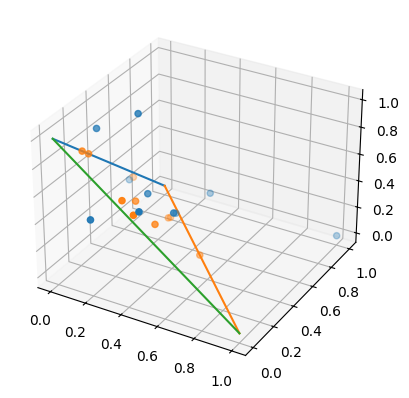

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(random_array[:,0], random_array[:,1], random_array[:,2])
# ax.scatter(x[:,0],x[:,1],x[:,2])
# ax.scatter([0],[0],[0])
ax.scatter(y[:,0],y[:,1],y[:,2])
ax.plot(xs=[0,0], ys=[1,0], zs=[0,1])
ax.plot(xs=[1,0], ys=[0,1], zs=[0,0])
ax.plot(xs=[0,1], ys=[0,0], zs=[1,0])

In [11]:
def project_and_clip_simplex(x):
  return clip_simplex(project_simplex(x))

In [12]:
def distance_matrix(x):
  # l2 norm gives nan grads (because x^0.5 = 0.5*x^-0.5, which is undef when x=0)
  # we avoid this case in computations using jnp.where in reisz_s_energy_loss
  # but apparently, both sides of where need to have non nan grads for it to work sigh
  # https://jax.readthedocs.io/en/latest/faq.html#gradients-contain-nan-where-using-where
  # hence edited everything to use "distance squared matrix"
  return jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=2)

def distance_squared_matrix(x):
  return jnp.sum((x[:,None,:] - x[None,:,:])**2, axis=2)

In [13]:
distance_squared_matrix(y)

Array([[0.        , 0.33347971, 0.5139402 , 0.45838448, 0.07897483,
        0.78769348, 0.07472096, 0.89292824, 0.28489016, 0.18098431],
       [0.33347971, 0.        , 0.36773264, 0.43056224, 0.09464755,
        0.25329284, 0.09253256, 0.33660332, 0.14901964, 0.23821433],
       [0.5139402 , 0.36773264, 0.        , 0.01076611, 0.43104016,
        0.12553045, 0.36672132, 0.12747403, 0.05686081, 0.08508939],
       [0.45838448, 0.43056224, 0.01076611, 0.        , 0.4337336 ,
        0.2088109 , 0.36733709, 0.21223359, 0.0734679 , 0.06723517],
       [0.07897483, 0.09464755, 0.43104016, 0.4337336 , 0.        ,
        0.50702705, 0.00278207, 0.61036318, 0.17971711, 0.16848283],
       [0.78769348, 0.25329284, 0.12553045, 0.2088109 , 0.50702705,
        0.        , 0.45576814, 0.00596912, 0.13499817, 0.27691175],
       [0.07472096, 0.09253256, 0.36672132, 0.36733709, 0.00278207,
        0.45576814, 0.        , 0.55127907, 0.14048666, 0.12802453],
       [0.89292824, 0.33660332, 0.1274740

In [14]:
def riesz_s_energy_loss(x, s=-1):
  # think because of https://jax.readthedocs.io/en/latest/faq.html#gradients-contain-nan-where-using-where
  # still need to add the 1e-10 in the knp.where
  distances_sqrd = distance_squared_matrix(x)
  return 0.5 * jnp.sum(jnp.where(distances_sqrd>0, 1/(distances_sqrd**(s/2) + 1e-16), 0))

In [15]:
riesz_s_energy_loss(x)

Array(25.37496524, dtype=float64)

In [16]:
jax.config.update("jax_debug_nans", False)

In [17]:

def generate_evenly_spread_points(num_points, dim, s, project_and_clip_fn, opt_lr, opt_iters, prng_key):
  num_free_points = num_points - dim
  free_points = jax.random.uniform(prng_key, shape=(num_free_points,dim), dtype=jnp.float64)
  free_points = project_and_clip_fn(free_points)

  s = jnp.where(s==-1, dim**2, s)

  def loss_fn(ps):
    return jnp.log(riesz_s_energy_loss(jnp.concatenate((jnp.eye(dim),ps), axis=0), s=s) + 1e-10)

  grad_loss_fn = jax.grad(loss_fn)

  optimizer = optax.adam(opt_lr)
  opt_state = optimizer.init(free_points)

  def loop_fn(iter, loop_state):
    free_points, opt_state = loop_state
    grads = grad_loss_fn(free_points)
    updates, opt_state = optimizer.update(grads, opt_state)
    free_points = optax.apply_updates(free_points, updates)
    free_points = project_and_clip_fn(free_points)
    return (free_points, opt_state)

  free_points, opt_state = jax.lax.fori_loop(0, opt_iters, jax.jit(loop_fn), (free_points, opt_state))

  # for _ in range(opt_iters):
  #   grads = grad_loss_fn(free_points)
  #   updates, opt_state = optimizer.update(grads, opt_state)
  #   free_points = optax.apply_updates(free_points, updates)
  #   free_points = project_and_clip_fn(free_points)

  return jnp.concatenate((jnp.eye(dim),free_points), axis=0)

In [18]:
def plot_points(points):
  fig = plt.figure()
  ax = fig.add_subplot(projection='3d')
  ax.scatter(points[:,0], points[:,1], points[:,2])

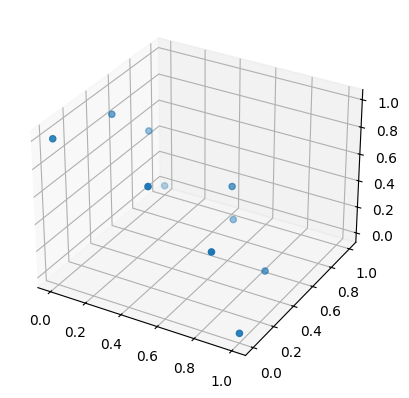

In [19]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=10,
    dim=3,
    s=2,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)
plot_points(sphere_points)

In [20]:
sphere_points

Array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.84705589, 0.53150382, 0.        ],
       [0.        , 0.85072089, 0.52561769],
       [0.51613708, 0.        , 0.85650599],
       [0.84994429, 0.        , 0.52687257],
       [0.62733719, 0.59141207, 0.50663578],
       [0.        , 0.51073219, 0.85973986],
       [0.4768307 , 0.87899516, 0.        ]], dtype=float64)

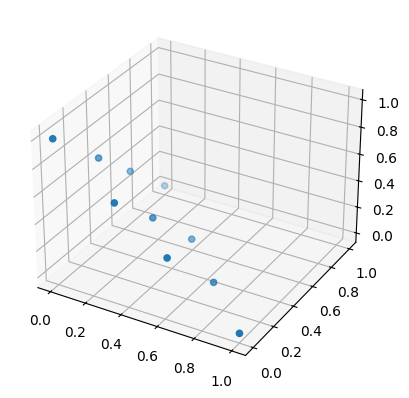

In [21]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=10,
  dim=3,
  s=2,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

In [22]:
simplex_points

Array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.61409198, 0.        , 0.38590802],
       [0.        , 0.66821236, 0.33178764],
       [0.33117218, 0.        , 0.66882782],
       [0.33335942, 0.33533834, 0.33130224],
       [0.39008766, 0.60991234, 0.        ],
       [0.        , 0.38244274, 0.61755726],
       [0.68141524, 0.31858476, 0.        ]], dtype=float64)

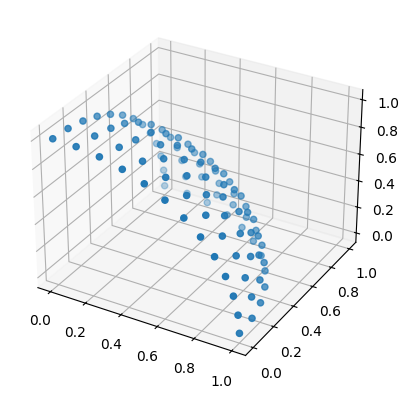

In [23]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=100,
    dim=3,
    s=9,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)

plot_points(sphere_points)

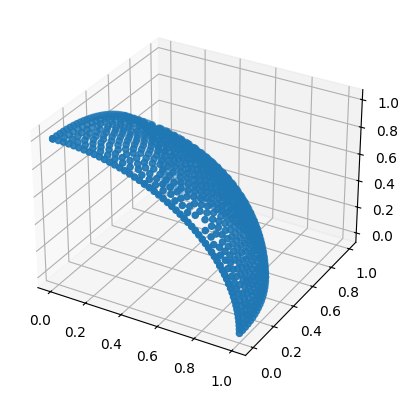

In [24]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=1000,
    dim=3,
    s=9,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)

plot_points(sphere_points)

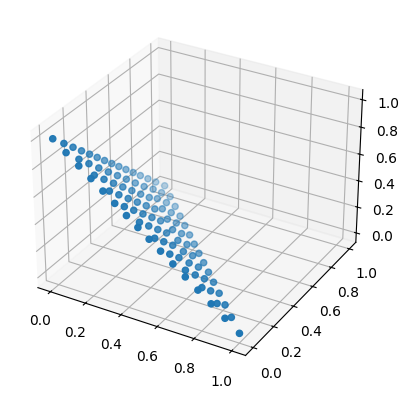

In [25]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=100,
  dim=3,
  s=9,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

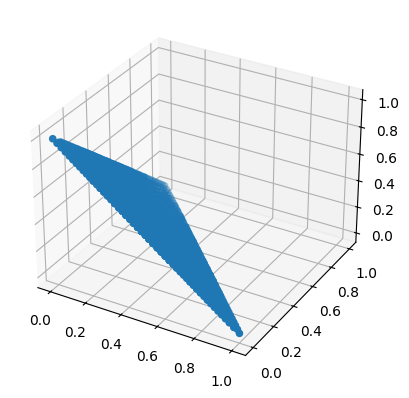

In [26]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=1000,
  dim=3,
  s=9,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

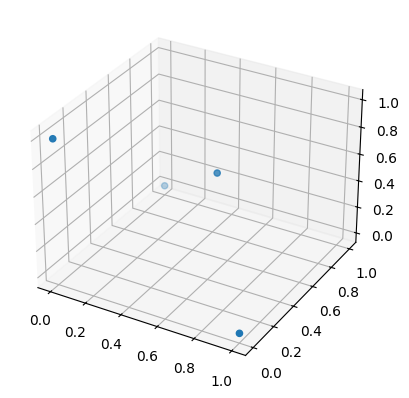

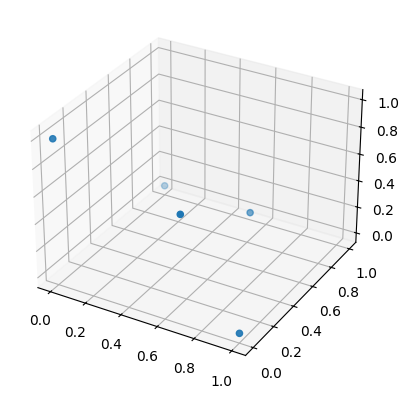

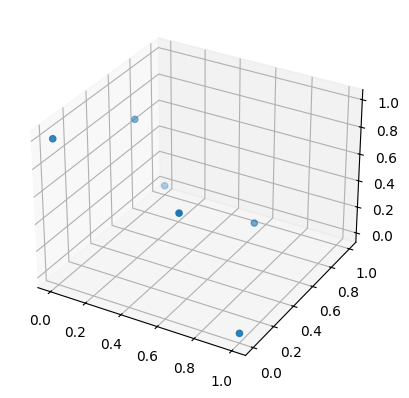

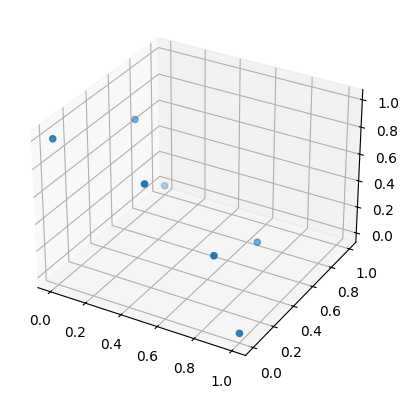

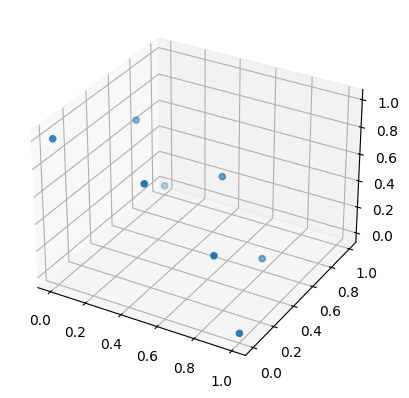

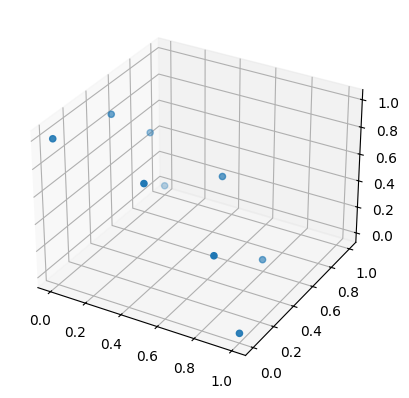

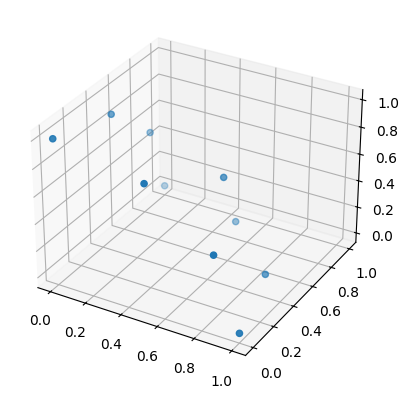

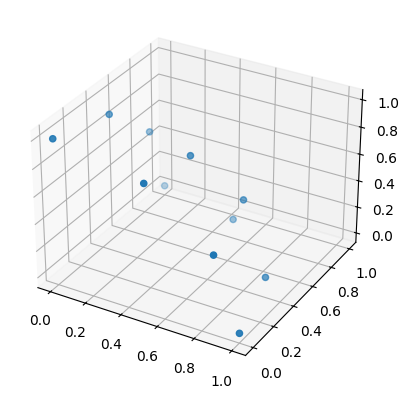

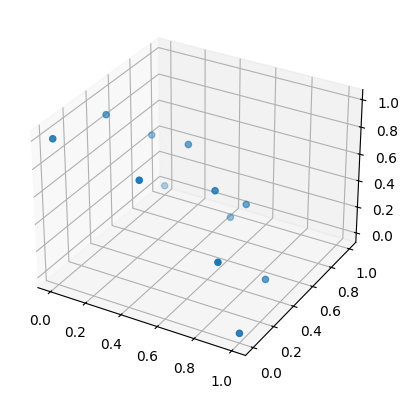

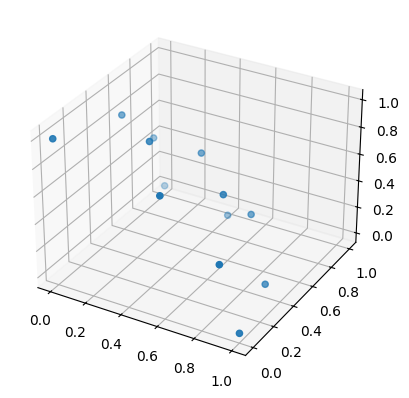

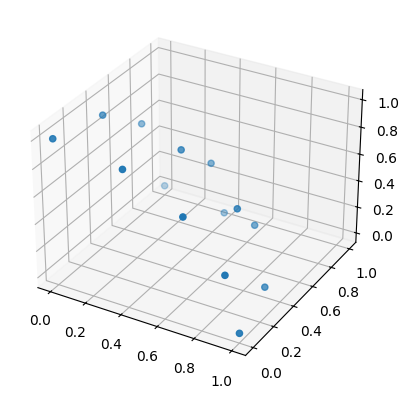

In [27]:
for i in range(4,15):
  prng_key = jax.random.PRNGKey(60415)
  sphere_points = generate_evenly_spread_points(
      num_points=i,
      dim=3,
      s=9,
      project_and_clip_fn=project_and_clip_hypersphere,
      opt_lr=0.01,
      opt_iters=1000,
      prng_key=prng_key)

  plot_points(sphere_points)

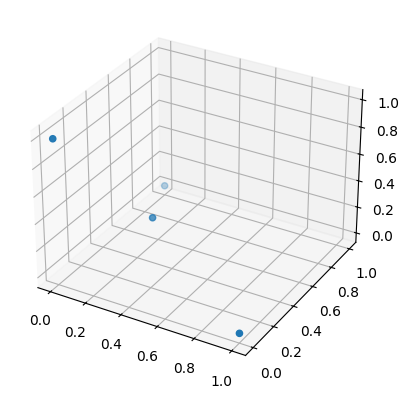

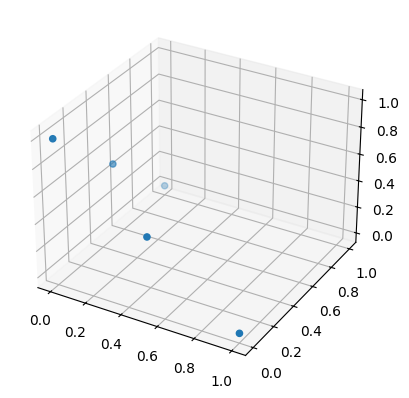

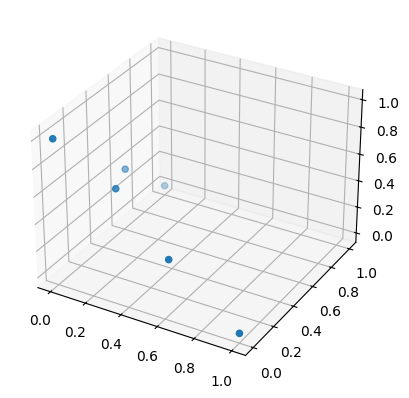

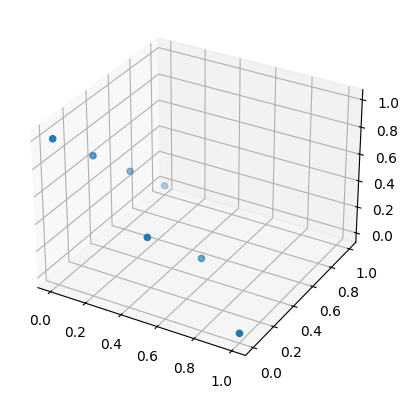

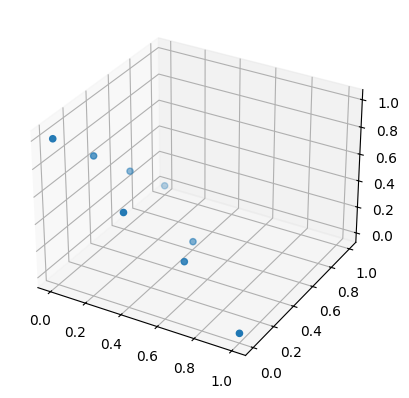

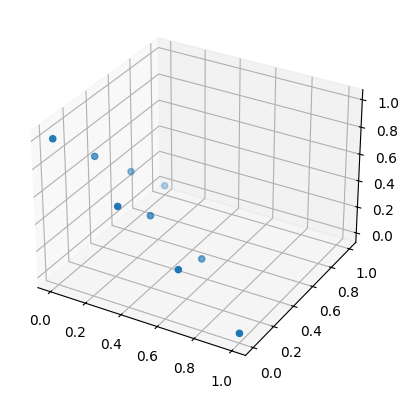

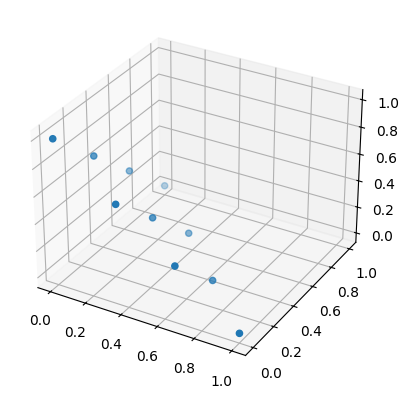

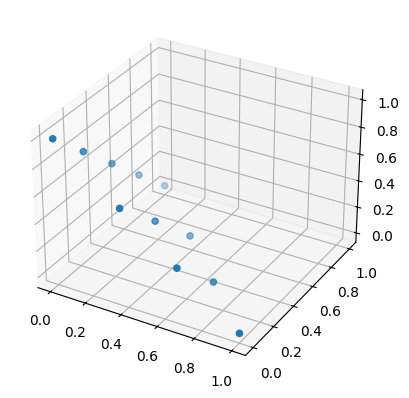

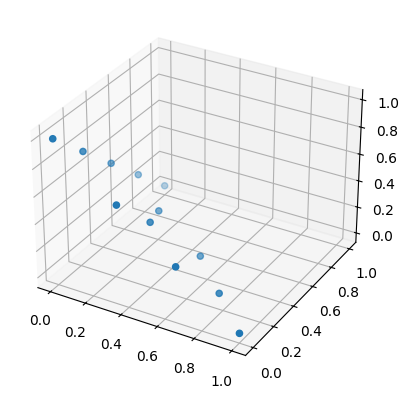

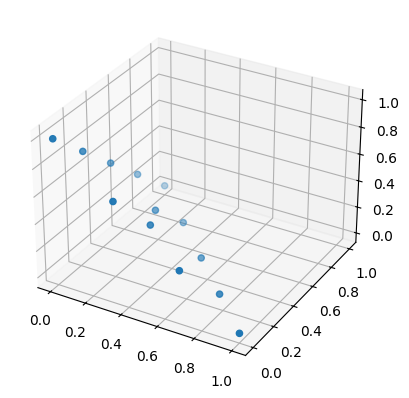

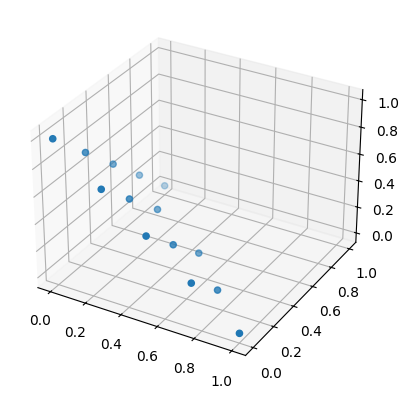

In [28]:
for i in range(4,15):
  prng_key = jax.random.PRNGKey(60415)
  sphere_points = generate_evenly_spread_points(
      num_points=i,
      dim=3,
      s=9,
      project_and_clip_fn=project_and_clip_simplex,
      opt_lr=0.01,
      opt_iters=1000,
      prng_key=prng_key)

  plot_points(sphere_points)

In [29]:
jax.__version__

'0.8.2'

In [30]:
def distances_loss(x):
  return jnp.sum(jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=1))
jax.grad(distances_loss)(x)

Array([[ 7.95955594,  5.97405017, -8.61252942],
       [-4.79321667,  5.39530802, -0.88575427],
       [ 1.08203702, -5.21126836,  3.24070384],
       [ 3.15187259, -5.7433549 ,  2.53551974],
       [ 0.59957985,  5.04139539, -4.04962314],
       [-6.54554658, -2.29147229,  5.58306645],
       [ 0.92820367,  4.3276019 , -3.65716863],
       [-5.68038993, -3.36911805,  5.5176373 ],
       [-0.03594172, -1.56584233,  0.97972405],
       [ 3.33384584, -2.55729954, -0.65157593]], dtype=float64)

In [31]:
def distances_loss_err(x):
  return jnp.sum(jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=-1))
jax.grad(distances_loss_err)(x)

Array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=float64)

In [1]:
from generate_well_spaced_vectors import generate_well_spaced_points, project_and_clip_simplex, generate_well_spaced_simplex_points_2d, generate_well_spaced_hypersphere_points_2d

In [ ]:


simplex_points = generate_well_spaced_points(4096, 3, project_and_clip_simplex)

Iteration 0 / 5000 (0.0%)
Iteration 1 / 5000 (0.0%)
Iteration 2 / 5000 (0.0%)
Iteration 3 / 5000 (0.1%)
Iteration 4 / 5000 (0.1%)
Iteration 5 / 5000 (0.1%)
Iteration 6 / 5000 (0.1%)
Iteration 7 / 5000 (0.1%)
Iteration 8 / 5000 (0.2%)
Iteration 9 / 5000 (0.2%)
Iteration 10 / 5000 (0.2%)
Iteration 11 / 5000 (0.2%)
Iteration 12 / 5000 (0.2%)
Iteration 13 / 5000 (0.3%)
Iteration 14 / 5000 (0.3%)
Iteration 15 / 5000 (0.3%)
Iteration 16 / 5000 (0.3%)
Iteration 17 / 5000 (0.3%)
Iteration 18 / 5000 (0.4%)
Iteration 19 / 5000 (0.4%)
Iteration 20 / 5000 (0.4%)
Iteration 21 / 5000 (0.4%)
Iteration 22 / 5000 (0.4%)
Iteration 23 / 5000 (0.5%)
Iteration 24 / 5000 (0.5%)
Iteration 25 / 5000 (0.5%)
Iteration 26 / 5000 (0.5%)
Iteration 27 / 5000 (0.5%)
Iteration 28 / 5000 (0.6%)
Iteration 29 / 5000 (0.6%)
Iteration 30 / 5000 (0.6%)
Iteration 31 / 5000 (0.6%)
Iteration 32 / 5000 (0.6%)
Iteration 33 / 5000 (0.7%)
Iteration 34 / 5000 (0.7%)
Iteration 35 / 5000 (0.7%)
Iteration 36 / 5000 (0.7%)
Iteration 3

In [38]:
print(type(simplex_points))
simplex_points

<class 'jaxlib._jax.ArrayImpl'>


Array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       ...,
       [0.        , 0.63476061, 0.36523939],
       [0.21764144, 0.56811037, 0.21424819],
       [0.23122269, 0.47894538, 0.28983194]], dtype=float64)

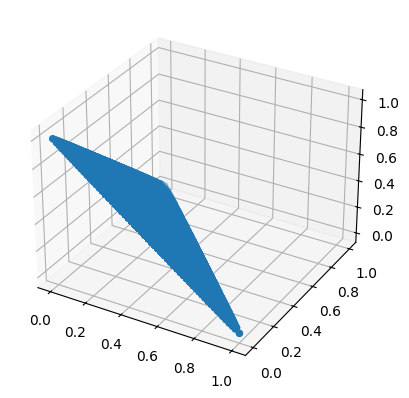

In [37]:
plot_points(simplex_points)

In [40]:
simplex_points[0:10]

Array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.23186038, 0.09318634, 0.67495328],
       [0.        , 0.83197491, 0.16802509],
       [0.28607632, 0.        , 0.71392368],
       [0.24962207, 0.0747029 , 0.67567502],
       [0.04327962, 0.61651586, 0.34020453],
       [0.        , 0.53173392, 0.46826608],
       [0.14646877, 0.77952269, 0.07400854]], dtype=float64)

In [41]:
simplex_points[10:20]

Array([[0.        , 0.42475789, 0.57524211],
       [0.10966571, 0.30486988, 0.58546441],
       [0.39583399, 0.21526326, 0.38890275],
       [0.28079656, 0.2122432 , 0.50696024],
       [0.69971403, 0.30028597, 0.        ],
       [0.        , 0.81574268, 0.18425732],
       [0.6259532 , 0.3740468 , 0.        ],
       [0.69868286, 0.2275723 , 0.07374484],
       [0.33386314, 0.19441316, 0.4717237 ],
       [0.42342633, 0.0773556 , 0.49921807]], dtype=float64)

In [2]:
generate_well_spaced_simplex_points_2d(10)

Array([[0.        , 1.        ],
       [0.11111111, 0.8888889 ],
       [0.22222222, 0.7777778 ],
       [0.33333334, 0.6666666 ],
       [0.44444445, 0.5555556 ],
       [0.5555556 , 0.44444442],
       [0.6666667 , 0.3333333 ],
       [0.7777778 , 0.22222221],
       [0.8888889 , 0.1111111 ],
       [1.        , 0.        ]], dtype=float32)

In [3]:
generate_well_spaced_hypersphere_points_2d(10)

Array([[ 1.0000000e+00,  0.0000000e+00],
       [ 9.8480773e-01,  1.7364819e-01],
       [ 9.3969262e-01,  3.4202015e-01],
       [ 8.6602539e-01,  5.0000000e-01],
       [ 7.6604444e-01,  6.4278764e-01],
       [ 6.4278758e-01,  7.6604450e-01],
       [ 4.9999997e-01,  8.6602545e-01],
       [ 3.4202006e-01,  9.3969268e-01],
       [ 1.7364810e-01,  9.8480779e-01],
       [-4.3711388e-08,  1.0000000e+00]], dtype=float32)

In [4]:
import jax.numpy as jnp
jnp.cos(jnp.pi / 2.0)

Array(-4.371139e-08, dtype=float32, weak_type=True)